In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from nexuskan import *
from nexuskan import KAN
from nexuskan import nexusKAN

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [23]:
class InteractKANWithFC(nn.Module):
    def __init__(self, kan_width=[2, 2], output_dim=1):
        super(InteractKANWithFC, self).__init__()
        self.kan_width = kan_width.copy()
        self.kan1 = nexusKAN(width=kan_width, 
                             grid=5, k=3, 
                            #  grid_range=[1.0, 15.0],
                             seed=42, device=device)

        self.fc = nn.Linear(self.kan_width[-1], output_dim)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.kan1(x)
        x = self.fc(x)
        x = self.sigmoid(x)
        
        return x

In [24]:
def get_tau(step, total_steps, tau_start=5.0, tau_end=0.5):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

def get_lr(epoch, epochs, lr_start=1e-1, lr_end=1e-2):
    return lr_start * (lr_end / lr_start) ** (epoch / epochs)

def get_lamb(epoch, epochs, lamb_start=1e-1, lamb_end=1e-2):
    return lamb_start * (lamb_end / lamb_start) ** (epoch / epochs)

def fit_model(model, dataset, lr=0.1, batch_size=64, epochs=100, logits_requires_grad=True, splines_requires_grad=True):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    # Коэффициенты регуляризации
    lamb_l1_acts = 1e-1  # для L1 активаций 1.
    lamb_ent_acts = 1e-1  # для энтропии активаций 2.

    for epoch in range(epochs):
        batches = dataset['train_input'].shape[0] // batch_size
        for batch_idx in range(batches):
            start = batch_idx * batch_size
            end = start + batch_size if batch_idx != batches - 1 else dataset['train_input'].shape[0]
            indices = torch.arange(start, end)
            batch_x = dataset['train_input'][indices]
            batch_y = dataset['train_label'][indices]
            
            for param_group in optimizer.param_groups:
                param_group['lr'] = get_lr(epoch, epochs, lr_start=lr, lr_end=1e-2)
            
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    module.logits.requires_grad = logits_requires_grad
                    
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    module.scale_base.requires_grad = splines_requires_grad
                    module.scale_sp.requires_grad = splines_requires_grad
                    module.coef.requires_grad = splines_requires_grad
                   
            # new_tau = 2.0 
            new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.1)
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    module.tau = new_tau
                    
            # if epoch % 1000 == 0:
            #     model.update_grid(batch_x)

            outputs = model(batch_x)
            train_loss = criterion(outputs, batch_y)
            
            # --- Энтропийная регуляризация вероятностей операций ---
            # lamb_ent_ops = 1.0
            lamb_ent_ops = get_lamb(epoch, epochs, lamb_start=1e-2, lamb_end=10.0)
            
            # lamb_l1_acts = get_lamb(epoch, epochs, lamb_start=1e-6, lamb_end=1e-3)
            # lamb_ent_acts = get_lamb(epoch, epochs, lamb_start=1e-6, lamb_end=1e-3)
            
            entropy_ops = 0.0
            num_layers_ops = 0
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    probs = torch.softmax(module.logits / module.tau, dim=-1)  # (in_dim, out_dim, groups+1)
                    eps = 1e-8
                    entropy_i = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # (in_dim, out_dim)
                    entropy_ops += entropy_i.mean()
                    num_layers_ops += 1
            entropy_ops_avg = entropy_ops / num_layers_ops if num_layers_ops > 0 else 0.0
            
            # --- Регуляризация активаций (L1 и энтропия) ---
            l1_acts = 0.0
            entropy_acts = 0.0
            num_layers_acts = 0
            for acts in model.kan1.acts_scale_spline:
                l1_acts += torch.sum(acts)
                # Энтропия по строкам и столбцам
                p_row = acts / (torch.sum(acts, dim=1, keepdim=True) + 1e-8)
                p_col = acts / (torch.sum(acts, dim=0, keepdim=True) + 1e-8)
                entropy_row = -torch.mean(torch.sum(p_row * torch.log2(p_row + 1e-8), dim=1))
                entropy_col = -torch.mean(torch.sum(p_col * torch.log2(p_col + 1e-8), dim=0))
                entropy_acts += entropy_row + entropy_col
                num_layers_acts += 1
            l1_acts_avg = l1_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            entropy_acts_avg = entropy_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            
            lamb = 0.0001
            lp_reg = sum(torch.norm(p, 1) for p in model.parameters())

            loss = train_loss + lamb_ent_ops * entropy_ops_avg + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg # + lamb * lp_reg
            # loss = train_loss + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        with torch.no_grad():
            test_outputs = model(dataset['test_input'])
            test_loss = criterion(test_outputs, dataset['test_label'])
        
        if (epoch + 1) % 10 == 0:
            print(f'--- Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')#, reg: {l1_reg:.4f}')


# 1

In [42]:
end_range = 1.0
start_range = -1.0
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 2) + start_range
y = torch.sin(2 * torch.pi * x[:, 0]) + torch.sin(2 * torch.pi * x[:, 1])
y_class = torch.where(y > 0.0, 1.0, 0.0)
dataset = {
    'train_input': x[:num_samples],
    'train_label': y_class[:num_samples].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y_class[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)

print(dataset['train_input'].shape, dataset['train_label'].shape)
print(torch.unique(dataset['train_label'], return_counts=True))
print(torch.unique(dataset['test_label'], return_counts=True))

torch.Size([1000, 2]) torch.Size([1000, 1])
(tensor([0., 1.], device='cuda:0'), tensor([482, 518], device='cuda:0'))
(tensor([0., 1.], device='cuda:0'), tensor([ 99, 101], device='cuda:0'))


In [26]:
model = InteractKANWithFC(kan_width=[2, 2], output_dim=1)
model = model.to(device=device)

checkpoint directory created: ./model
saving model version 0.0


In [27]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=64, 
          epochs=100)

--- Epoch [10/100], Train Loss: 0.2536, Test Loss: 0.1835
--- Epoch [20/100], Train Loss: 0.2008, Test Loss: 0.1473
--- Epoch [30/100], Train Loss: 0.1794, Test Loss: 0.1341
--- Epoch [40/100], Train Loss: 0.1722, Test Loss: 0.1296
--- Epoch [50/100], Train Loss: 0.1649, Test Loss: 0.1266
--- Epoch [60/100], Train Loss: 0.1614, Test Loss: 0.1217
--- Epoch [70/100], Train Loss: 0.1752, Test Loss: 0.1181
--- Epoch [80/100], Train Loss: 0.1749, Test Loss: 0.1176
--- Epoch [90/100], Train Loss: 0.1744, Test Loss: 0.1184
--- Epoch [100/100], Train Loss: 0.1726, Test Loss: 0.1181


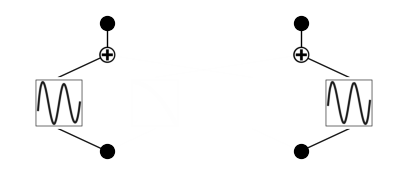

In [28]:
model.kan1.plot()

In [ ]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0., 1.],
         [1., 0.]],

        [[0., 1.],
         [0., 1.]]], device='cuda:0', grad_fn=<RoundBackward1>)


# 2

In [43]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 4) + start_range
y_class = x[:, 0] / x[:, 3] + x[:, 1] / x[:, 2]
# print(y)
y_class = torch.where(y_class > 2.2, 1.0, 0.0)
dataset = {
    'train_input': x[:1000],
    'train_label': y_class[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y_class[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)

print(dataset['train_input'].shape, dataset['train_label'].shape)
print(torch.unique(dataset['train_label'], return_counts=True))
print(torch.unique(dataset['test_label'], return_counts=True))

torch.Size([1000, 4]) torch.Size([1000, 1])
(tensor([0., 1.], device='cuda:0'), tensor([471, 529], device='cuda:0'))
(tensor([0., 1.], device='cuda:0'), tensor([ 82, 118], device='cuda:0'))


In [44]:
model = InteractKANWithFC(kan_width=[4, 2], output_dim=1)
model = model.to(device=device)

checkpoint directory created: ./model
saving model version 0.0


In [45]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=64, 
          epochs=200)

--- Epoch [10/200], Train Loss: 0.2861, Test Loss: 0.2559
--- Epoch [20/200], Train Loss: 0.2292, Test Loss: 0.2106
--- Epoch [30/200], Train Loss: 0.2325, Test Loss: 0.2043
--- Epoch [40/200], Train Loss: 0.2255, Test Loss: 0.2033
--- Epoch [50/200], Train Loss: 0.2189, Test Loss: 0.1929
--- Epoch [60/200], Train Loss: 0.2114, Test Loss: 0.1938
--- Epoch [70/200], Train Loss: 0.2034, Test Loss: 0.2075
--- Epoch [80/200], Train Loss: 0.1984, Test Loss: 0.1964
--- Epoch [90/200], Train Loss: 0.2026, Test Loss: 0.2039
--- Epoch [100/200], Train Loss: 0.1980, Test Loss: 0.1971
--- Epoch [110/200], Train Loss: 0.1957, Test Loss: 0.1940
--- Epoch [120/200], Train Loss: 0.1977, Test Loss: 0.1944
--- Epoch [130/200], Train Loss: 0.1920, Test Loss: 0.2044
--- Epoch [140/200], Train Loss: 0.1915, Test Loss: 0.1950
--- Epoch [150/200], Train Loss: 0.1950, Test Loss: 0.2058
--- Epoch [160/200], Train Loss: 0.1938, Test Loss: 0.1955
--- Epoch [170/200], Train Loss: 0.1915, Test Loss: 0.2000
--- Ep

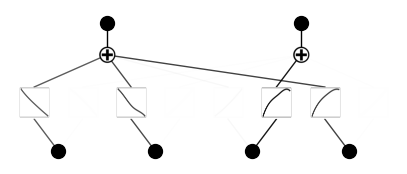

In [46]:
model.kan1.plot()

In [ ]:
for module in model.modules():
    if isinstance(module, NexusKANLayer):
        probs = torch.softmax(module.logits / module.tau, dim=-1)
        rounded_probs = probs.round(decimals=3)
        print(rounded_probs)

tensor([[[0., 1., 0.],
         [0., 0., 1.]],

        [[0., 0., 1.],
         [0., 0., 1.]],

        [[0., 0., 1.],
         [1., 0., 0.]],

        [[0., 0., 1.],
         [1., 0., 0.]]], device='cuda:0', grad_fn=<RoundBackward1>)


# 3

In [ ]:
def get_tau(step, total_steps, tau_start=5.0, tau_end=0.5):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

def get_lr(epoch, epochs, lr_start=1e-1, lr_end=1e-2):
    return lr_start * (lr_end / lr_start) ** (epoch / epochs)

def get_lamb(epoch, epochs, lamb_start=1e-1, lamb_end=1e-2):
    return lamb_start * (lamb_end / lamb_start) ** (epoch / epochs)

def fit_model(model, dataset, lr=0.1, batch_size=512, epochs=1000, logits_requires_grad=True, splines_requires_grad=True):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    # Коэффициенты регуляризации
    lamb_l1_acts = 1e-2  # для L1 активаций 1.
    lamb_ent_acts = 1e-1  # для энтропии активаций 2.

    for epoch in range(epochs):
        batches = dataset['train_input'].shape[0] // batch_size
        for batch_idx in range(batches):
            start = batch_idx * batch_size
            end = start + batch_size if batch_idx != batches - 1 else dataset['train_input'].shape[0]
            indices = torch.arange(start, end)
            batch_x = dataset['train_input'][indices]
            batch_y = dataset['train_label'][indices]
            
            for param_group in optimizer.param_groups:
                param_group['lr'] = get_lr(epoch, epochs, lr_start=lr, lr_end=1e-2)
            
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    module.logits.requires_grad = logits_requires_grad
                    
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    module.scale_base.requires_grad = splines_requires_grad
                    module.scale_sp.requires_grad = splines_requires_grad
                    module.coef.requires_grad = splines_requires_grad
                   
            new_tau = 2.0 
            # new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.1)
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    module.tau = new_tau
                    
            # if epoch % 1000 == 0:
            #     model.update_grid(batch_x)

            outputs = model(batch_x)
            train_loss = criterion(outputs, batch_y)
            
            # --- Энтропийная регуляризация вероятностей операций ---
            lamb_ent_ops = 1.0
            # lamb_ent_ops = get_lamb(epoch, epochs, lamb_start=1e-2, lamb_end=10.0)
            
            entropy_ops = 0.0
            num_layers_ops = 0
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    probs = torch.softmax(module.logits / module.tau, dim=-1)  # (in_dim, out_dim, groups+1)
                    eps = 1e-8
                    entropy_i = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # (in_dim, out_dim)
                    entropy_ops += entropy_i.mean()
                    num_layers_ops += 1
            entropy_ops_avg = entropy_ops / num_layers_ops if num_layers_ops > 0 else 0.0
            
            # --- Регуляризация активаций (L1 и энтропия) ---
            l1_acts = 0.0
            entropy_acts = 0.0
            num_layers_acts = 0
            for acts in model.acts_scale_spline:
                l1_acts += torch.sum(acts)
                # Энтропия по строкам и столбцам
                p_row = acts / (torch.sum(acts, dim=1, keepdim=True) + 1e-8)
                p_col = acts / (torch.sum(acts, dim=0, keepdim=True) + 1e-8)
                entropy_row = -torch.mean(torch.sum(p_row * torch.log2(p_row + 1e-8), dim=1))
                entropy_col = -torch.mean(torch.sum(p_col * torch.log2(p_col + 1e-8), dim=0))
                entropy_acts += entropy_row + entropy_col
                num_layers_acts += 1
            l1_acts_avg = l1_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            entropy_acts_avg = entropy_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            
            lamb = 0.0001
            lp_reg = sum(torch.norm(p, 1) for p in model.parameters())

            loss = train_loss + lamb_ent_ops * entropy_ops_avg + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg # + lamb * lp_reg
            # loss = train_loss + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        with torch.no_grad():
            test_outputs = model(dataset['test_input'])
            test_loss = criterion(test_outputs, dataset['test_label'])
        
        if (epoch + 1) % 10 == 0:
            print(f'--- Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')#, reg: {l1_reg:.4f}')


checkpoint directory created: ./model
saving model version 0.0


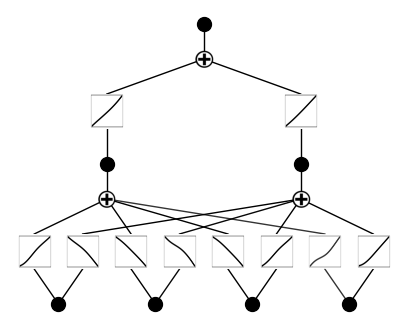

In [ ]:
model = nexusKAN(width=[4, 2, 1], grid=5, k=3, seed=42, device=device)
model(dataset['train_input'])
model.plot()

In [ ]:
fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=512, 
          epochs=1000)

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


/pytorch/aten/src/ATen/native/cuda/Loss.cu:90: operator(): block: [0,0,0], thread: [77,0,0] Assertion `input_val >= zero && input_val <= one` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:90: operator(): block: [0,0,0], thread: [21,0,0] Assertion `input_val >= zero && input_val <= one` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:90: operator(): block: [0,0,0], thread: [35,0,0] Assertion `input_val >= zero && input_val <= one` failed.
/pytorch/aten/src/ATen/native/cuda/Loss.cu:90: operator(): block: [0,0,0], thread: [59,0,0] Assertion `input_val >= zero && input_val <= one` failed.


In [47]:
class InteractKANWithFC(nn.Module):
    def __init__(self, kan_width=[4, 8, 1], output_dim=1):
        super(InteractKANWithFC, self).__init__()
        self.kan_width = kan_width.copy()
        self.kan1 = nexusKAN(width=kan_width, 
                             grid=5, k=3, 
                             grid_range=[0.1, 1.0],
                             seed=42, device=device)

        self.fc = nn.Linear(self.kan_width[-1], output_dim)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.kan1(x)
        x = self.fc(x)
        x = self.sigmoid(x)
        
        return x

In [48]:
def get_tau(step, total_steps, tau_start=5.0, tau_end=0.5):
    return tau_start * (tau_end / tau_start) ** (step / total_steps)

def get_lr(epoch, epochs, lr_start=1e-1, lr_end=1e-3):
    return lr_start * (lr_end / lr_start) ** (epoch / epochs)

def get_lamb(epoch, epochs, lamb_start=1e-2, lamb_end=1e-3):
    return lamb_start * (lamb_end / lamb_start) ** (epoch / epochs)

def fit_model(model, dataset, lr=0.1, batch_size=64, epochs=300, logits_requires_grad=True, splines_requires_grad=True):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    # Коэффициенты регуляризации
    lamb_l1_acts = 1e-2  # для L1 активаций 1.
    lamb_ent_acts = 1e-2  # для энтропии активаций 2.

    for epoch in range(epochs):
        batches = dataset['train_input'].shape[0] // batch_size
        for batch_idx in range(batches):
            start = batch_idx * batch_size
            end = start + batch_size if batch_idx != batches - 1 else dataset['train_input'].shape[0]
            indices = torch.arange(start, end)
            batch_x = dataset['train_input'][indices]
            batch_y = dataset['train_label'][indices]
            
            for param_group in optimizer.param_groups:
                param_group['lr'] = get_lr(epoch, epochs, lr_start=lr, lr_end=1e-3)
             
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    module.logits.requires_grad = logits_requires_grad
                     
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    module.scale_base.requires_grad = splines_requires_grad
                    module.scale_sp.requires_grad = splines_requires_grad
                    module.coef.requires_grad = splines_requires_grad
                    
            # new_tau = 2.0 
            new_tau = get_tau(epoch, epochs, tau_start=2.0, tau_end=0.1)
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    module.tau = new_tau
                     
            # if epoch % 1000 == 0:
            #     model.update_grid(batch_x)

            outputs = model(batch_x)
            train_loss = criterion(outputs, batch_y)
            
            # --- Энтропийная регуляризация вероятностей операций ---
            # lamb_ent_ops = 1.0
            lamb_ent_ops = get_lamb(epoch, epochs, lamb_start=1e-2, lamb_end=10.0)
            
            # lamb_l1_acts = get_lamb(epoch, epochs, lamb_start=1e-6, lamb_end=1e-3)
            # lamb_ent_acts = get_lamb(epoch, epochs, lamb_start=1e-6, lamb_end=1e-3)
            
            entropy_ops = 0.0
            num_layers_ops = 0
            for module in model.modules():
                if isinstance(module, NexusKANLayer):
                    probs = torch.softmax(module.logits / module.tau, dim=-1)  # (in_dim, out_dim, groups+1)
                    eps = 1e-8
                    entropy_i = -torch.sum(probs * torch.log(probs + eps), dim=-1)  # (in_dim, out_dim)
                    entropy_ops += entropy_i.mean()
                    num_layers_ops += 1
            entropy_ops_avg = entropy_ops / num_layers_ops if num_layers_ops > 0 else 0.0
            
            # --- Регуляризация активаций (L1 и энтропия) ---
            l1_acts = 0.0
            entropy_acts = 0.0
            num_layers_acts = 0
            for acts in model.kan1.acts_scale_spline:
                l1_acts += torch.sum(acts)
                # Энтропия по строкам и столбцам
                p_row = acts / (torch.sum(acts, dim=1, keepdim=True) + 1e-8)
                p_col = acts / (torch.sum(acts, dim=0, keepdim=True) + 1e-8)
                entropy_row = -torch.mean(torch.sum(p_row * torch.log2(p_row + 1e-8), dim=1))
                entropy_col = -torch.mean(torch.sum(p_col * torch.log2(p_col + 1e-8), dim=0))
                entropy_acts += entropy_row + entropy_col
                num_layers_acts += 1
            l1_acts_avg = l1_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            entropy_acts_avg = entropy_acts / num_layers_acts if num_layers_acts > 0 else 0.0
            
            lamb = 0.0001
            lp_reg = sum(torch.norm(p, 1) for p in model.parameters())

            loss = train_loss + lamb_ent_ops * entropy_ops_avg + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg # + lamb * lp_reg
            # loss = train_loss + lamb_l1_acts * l1_acts_avg + lamb_ent_acts * entropy_acts_avg
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        
        with torch.no_grad():
            test_outputs = model(dataset['test_input'])
            test_loss = criterion(test_outputs, dataset['test_label'])
        
        if (epoch + 1) % 10 == 0:
            print(f'--- Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, Test Loss: {test_loss.item():.4f}')#, reg: {l1_reg:.4f}')

In [49]:
end_range = 1.0
start_range = 0.1
num_samples = 1000
x = (end_range - start_range) * torch.rand(num_samples + 200, 4) + start_range
y_class_raw = x[:, 0] / x[:, 3] + x[:, 1] / x[:, 2]
# Optional: normalize targets to [0,1] for potentially better learning
# y_class_norm = (y_class_raw - y_class_raw.min()) / (y_class_raw.max() - y_class_raw.min())
# y_class = torch.where(y_class_norm > 0.5, 1.0, 0.0)
y_class = torch.where(y_class_raw > 2.2, 1.0, 0.0)
dataset = {
    'train_input': x[:1000],
    'train_label': y_class[:1000].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y_class[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)

print(dataset['train_input'].shape, dataset['train_label'].shape)
print(torch.unique(dataset['train_label'], return_counts=True))
print(torch.unique(dataset['test_label'], return_counts=True))

torch.Size([1000, 4]) torch.Size([1000, 1])
(tensor([0., 1.], device='cuda:0'), tensor([505, 495], device='cuda:0'))
(tensor([0., 1.], device='cuda:0'), tensor([ 93, 107], device='cuda:0'))


In [50]:
model = InteractKANWithFC(kan_width=[4, 8, 1], output_dim=1)
model = model.to(device=device)

fit_model(model=model, 
          dataset=dataset, 
          lr=0.1, 
          batch_size=64, 
          epochs=300)

checkpoint directory created: ./model
saving model version 0.0
--- Epoch [10/300], Train Loss: 0.1043, Test Loss: 0.2342
--- Epoch [20/300], Train Loss: 0.0772, Test Loss: 0.2059
--- Epoch [30/300], Train Loss: 0.0625, Test Loss: 0.2009
--- Epoch [40/300], Train Loss: 0.0622, Test Loss: 0.1489
--- Epoch [50/300], Train Loss: 0.0411, Test Loss: 0.1708
--- Epoch [60/300], Train Loss: 0.0420, Test Loss: 0.1659
--- Epoch [70/300], Train Loss: 0.0503, Test Loss: 0.1399
--- Epoch [80/300], Train Loss: 0.0554, Test Loss: 0.1423
--- Epoch [90/300], Train Loss: 0.0518, Test Loss: 0.1353
--- Epoch [100/300], Train Loss: 0.0475, Test Loss: 0.1279
--- Epoch [110/300], Train Loss: 0.0527, Test Loss: 0.1287
--- Epoch [120/300], Train Loss: 0.0517, Test Loss: 0.1284
--- Epoch [130/300], Train Loss: 0.0647, Test Loss: 0.1436
--- Epoch [140/300], Train Loss: 0.0490, Test Loss: 0.1282
--- Epoch [150/300], Train Loss: 0.0427, Test Loss: 0.1284
--- Epoch [160/300], Train Loss: 0.0457, Test Loss: 0.1194
--

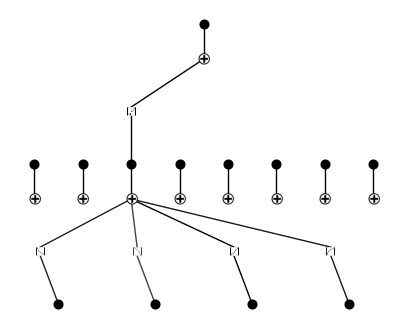

In [51]:
model.kan1.plot()